# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Husain Fadllullah
- **Email:** husainfadllullah4@gmail.com
- **ID Dicoding:** husainfadllullah

## Menentukan Pertanyaan Bisnis

1. **Pola jam sibuk.** Pada jam berapa permintaan penyewaan sepeda mencapai puncak pada hari kerja dibandingkan akhir pekan/hari libur sepanjang 2011-2012, dan berapa selisih rata-rata penyewaan per jam pada jam puncak sore (17:00) di antara keduanya, sehingga operator dapat menentukan jadwal redistribusi sepeda antar-stasiun?
2. **Pengaruh cuaca.** Seberapa besar penurunan rata-rata penyewaan harian pada kondisi hujan/salju ringan dan musim dingin dibandingkan cuaca cerah dan musim panas sepanjang 2011-2012, serta pada kategori suhu berapa penyewaan paling rendah, sehingga tim pemasaran dapat merancang promo dan jadwal perawatan armada?
3. **Perilaku pengguna.** Berapa persen kenaikan rata-rata penyewaan harian pengguna *casual* pada akhir pekan/hari libur dibandingkan hari kerja sepanjang 2011-2012, dan berapa porsinya terhadap total penyewaan, sehingga tim bisnis dapat menyusun program konversi pengguna casual menjadi registered?

*Penerapan SMART:* **Specific** (fokus pada jam, cuaca, dan tipe pengguna), **Measurable** (rata-rata sewa, selisih, persentase), **Action-oriented** (redistribusi sepeda, promo, program konversi), **Relevant** (efisiensi operasional dan pendapatan layanan bike sharing), **Time-bound** (periode 2011-2012).

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Palet warna konsisten: satu warna aksen untuk sorotan, abu-abu untuk konteks
C_ACCENT = "#D1495B"   # sorotan utama
C_BLUE = "#00798C"     # seri pembanding
C_GREY = "#B8B8B8"     # konteks / non-sorotan

## Data Wrangling

### Gathering Data
Dataset Bike Sharing terdiri dari dua berkas: `day.csv` (agregasi harian) dan `hour.csv` (agregasi per jam) untuk periode 2011-2012. `day.csv` dipakai untuk analisis tingkat harian (cuaca, musim, tipe pengguna), sedangkan `hour.csv` dipakai untuk pola per jam.

In [2]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

print("day.csv  :", day_df.shape)
print("hour.csv :", hour_df.shape)
day_df.head()

day.csv  : (731, 16)
hour.csv : (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.34,0.36,0.81,0.16,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.36,0.35,0.70,0.25,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.20,0.19,0.44,0.25,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.20,0.21,0.59,0.16,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.23,0.23,0.44,0.19,82,1518,1600


In [3]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


**Insight:**
- `day.csv` berisi 731 baris (1 baris per hari) dan `hour.csv` berisi 17.379 baris (1 baris per jam), mencakup 1 Januari 2011 sampai 31 Desember 2012.
- Kolom utama: `cnt` (total sewa), `casual` dan `registered` (tipe pengguna), `weathersit`, `season`, `temp`, `hum`, `windspeed`, `workingday`, dan `hr` (khusus data per jam).

### Assessing Data
Pada tahap ini kualitas data dinilai: tipe data, missing value, duplikat, nilai tidak valid/akurat, kelengkapan, dan outlier.

In [4]:
print("=== day_df ===")
day_df.info()
print()
print("=== hour_df ===")
hour_df.info()

=== day_df ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB

=== hour_df ===
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data column

In [5]:
print("Missing value day_df :", day_df.isna().sum().sum())
print("Missing value hour_df:", hour_df.isna().sum().sum())
print("Duplikat day_df      :", day_df.duplicated().sum())
print("Duplikat hour_df     :", hour_df.duplicated().sum())

Missing value day_df : 0
Missing value hour_df: 0
Duplikat day_df      : 0
Duplikat hour_df     : 0


Dataset tidak memiliki missing value maupun data duplikat. Namun, bukan berarti data sudah siap pakai. Pemeriksaan lebih lanjut di bawah menemukan beberapa masalah lain.

In [6]:
# Masalah 1: tipe data tanggal. dteday masih bertipe object (string)
print("Tipe dteday:", day_df["dteday"].dtype)

# Masalah 2: kode kategori. Cek nilai unik kolom kategoris
for col in ["season", "yr", "mnth", "weekday", "weathersit", "holiday", "workingday"]:
    print(f"{col:<11}:", sorted(hour_df[col].unique()))

Tipe dteday: str
season     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr         : [np.int64(0), np.int64(1)]
mnth       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
weekday    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
weathersit : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
holiday    : [np.int64(0), np.int64(1)]
workingday : [np.int64(0), np.int64(1)]


In [7]:
# Masalah 3: fitur numerik masih dalam skala ternormalisasi (0-1)
day_df[["temp", "atemp", "hum", "windspeed"]].describe().loc[["min", "max"]]

,temp,atemp,hum,windspeed
min,0.06,0.08,0.00,0.02
max,0.86,0.84,0.97,0.51


In [8]:
# Masalah 4: nilai tidak akurat (kelembapan/suhu terasa bernilai 0 tidak masuk akal)
print("hum == 0 (day_df)  :", (day_df["hum"] == 0).sum())
print("hum == 0 (hour_df) :", (hour_df["hum"] == 0).sum())
print("atemp == 0 (hour_df):", (hour_df["atemp"] == 0).sum())
print("windspeed == 0 (hour_df):", (hour_df["windspeed"] == 0).sum(),
      f"({(hour_df['windspeed'] == 0).mean():.1%} baris)")
print()
print("Tanggal dengan hum == 0 di hour_df:", hour_df.loc[hour_df["hum"] == 0, "dteday"].unique())

hum == 0 (day_df)  : 1
hum == 0 (hour_df) : 22
atemp == 0 (hour_df): 2
windspeed == 0 (hour_df): 2180 (12.5% baris)

Tanggal dengan hum == 0 di hour_df: <ArrowStringArray>
['2011-03-10']
Length: 1, dtype: str


In [9]:
# Masalah 5: jam yang hilang. Seharusnya 731 hari x 24 jam = 17.544 baris
expected = 731 * 24
print("Baris seharusnya :", expected)
print("Baris di hour_df :", len(hour_df))
print("Jam hilang       :", expected - len(hour_df))
print("Hari dengan < 24 jam data:", (hour_df.groupby("dteday").size() < 24).sum())

Baris seharusnya : 17544
Baris di hour_df : 17379
Jam hilang       : 165
Hari dengan < 24 jam data: 76


In [10]:
# Masalah 7: label musim. Readme menyebut 1=semi, 2=panas, 3=gugur, 4=dingin.
# Verifikasi dengan rentang tanggal tiap kode musim
print(day_df.assign(bulan=pd.to_datetime(day_df["dteday"]).dt.month_name())
      .groupby("season")["bulan"].agg(lambda s: sorted(s.unique(), key=lambda m: pd.to_datetime(m, format="%B").month)))

season
1        [January, February, March, December]
2                   [March, April, May, June]
3             [June, July, August, September]
4    [September, October, November, December]
Name: bulan, dtype: object


In [11]:
# Masalah 6: outlier (metode IQR)
def count_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

pd.DataFrame({
    "day_df": [count_outliers(day_df[c]) for c in ["cnt", "casual", "windspeed"]],
    "hour_df": [count_outliers(hour_df[c]) for c in ["cnt", "casual", "windspeed"]],
}, index=["cnt", "casual", "windspeed"])

,day_df,hour_df
cnt,0,505
casual,44,1192
windspeed,13,342


**Insight:** Selain tidak ada missing value dan duplikat, ditemukan 7 permasalahan yang perlu ditangani atau dicatat.

| No | Masalah | Jenis | Temuan | Tindakan di tahap Cleaning |
|---|---|---|---|---|
| 1 | `dteday` bertipe string | Invalid value (tipe data) | Kolom tanggal bertipe object | Ubah ke `datetime` |
| 2 | Kolom kategori berupa kode angka (`season`, `weathersit`, `weekday`, `yr`) | Inconsistent/tidak informatif | Nilai 0-6, 1-4 tanpa makna langsung | Petakan ke label teks |
| 3 | `temp`, `atemp`, `hum`, `windspeed` ternormalisasi | Inconsistent value (skala) | Rentang 0-1 | Kembalikan ke skala asli sesuai Readme |
| 4 | Kelembapan = 0 dan suhu terasa = 0 | Inaccurate value | 1 baris di `day_df`, 22 baris di `hour_df` (seluruhnya tanggal 2011-03-10), 2 baris `atemp` | Anggap hilang, isi dengan interpolasi linear |
| 5 | Jam tidak tercatat di `hour_df` | Missing record | 165 jam hilang di 76 hari | Lengkapi grid tanggal x jam, isi penyewaan = 0 |
| 6 | Label musim di Readme tidak cocok dengan tanggal | Inaccurate value | `season = 1` mencakup Januari-Maret dan akhir Desember, jadi sebenarnya musim dingin | Petakan sesuai kalender musim sebenarnya |
| 7 | Outlier pada `cnt` dan `casual` per jam, `windspeed` | Outlier | 505 baris outlier `cnt` per jam | **Dipertahankan.** Itu lonjakan permintaan nyata (jam sibuk), bukan kesalahan input |

Catatan tambahan: `windspeed = 0` muncul di 12,5% baris `hour_df`. Ini kemungkinan keterbatasan sensor, sehingga kolom tersebut tidak dipakai untuk menarik kesimpulan utama.

### Cleaning Data
Setiap masalah yang ditemukan pada tahap Assessing ditangani satu per satu di bawah ini.

**1) Tipe data tanggal.** `dteday` diubah ke `datetime` agar bisa difilter dan diurutkan berdasarkan waktu.

In [12]:
# 1) Ubah dteday menjadi datetime
for df in (day_df, hour_df):
    df["dteday"] = pd.to_datetime(df["dteday"])
    df.drop(columns="instant", inplace=True)   # hanya nomor urut, tidak dipakai

print(day_df["dteday"].dtype, hour_df["dteday"].dtype)

datetime64[us] datetime64[us]


**2) Jam yang hilang.** Grid lengkap tanggal x jam dibuat ulang. Jam yang tidak tercatat diasumsikan tidak ada penyewaan (`cnt = 0`), karena sistem hanya mencatat jam yang memiliki transaksi. Tanpa langkah ini rata-rata per jam, terutama dini hari, akan terlalu tinggi.

In [13]:
# 2) Lengkapi jam yang hilang -> jam tanpa penyewaan diisi 0
all_dates = pd.date_range("2011-01-01", "2012-12-31")
full_index = pd.MultiIndex.from_product([all_dates, range(24)], names=["dteday", "hr"])
hour_df = hour_df.set_index(["dteday", "hr"]).reindex(full_index).reset_index()

# Penyewaan pada jam yang hilang = 0
for col in ["casual", "registered", "cnt"]:
    hour_df[col] = hour_df[col].fillna(0).astype(int)

# Atribut harian (musim, tahun, hari kerja, dst.) diambil dari day_df
daily_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday"]
hour_df = hour_df.drop(columns=daily_cols).merge(day_df[["dteday"] + daily_cols], on="dteday", how="left")

# Atribut cuaca pada jam yang hilang diisi dengan nilai jam terdekat di hari yang sama
weather_cols = ["weathersit", "temp", "atemp", "hum", "windspeed"]
hour_df[weather_cols] = hour_df.groupby("dteday")[weather_cols].transform(lambda s: s.ffill().bfill())

print("Jumlah baris sekarang:", len(hour_df))
print("Missing value        :", hour_df.isna().sum().sum())

Jumlah baris sekarang: 17544
Missing value        : 0


**3) Nilai tidak akurat.** Kelembapan 0% dan suhu terasa 0 tidak masuk akal secara fisik, sehingga dianggap hilang dan diisi dengan interpolasi linear dari nilai di sekitarnya. Nilai `windspeed = 0` **tidak** diubah karena jumlahnya sangat besar dan kemungkinan berasal dari keterbatasan sensor. Kolom ini tidak dipakai untuk menarik kesimpulan utama.

In [14]:
# 3) Nilai tidak akurat: hum = 0 dan atemp = 0 dianggap hilang, lalu diinterpolasi secara linear
hour_df = hour_df.sort_values(["dteday", "hr"]).reset_index(drop=True)
day_df = day_df.sort_values("dteday").reset_index(drop=True)

day_df["hum"] = day_df["hum"].replace(0, np.nan).interpolate(limit_direction="both")
hour_df["hum"] = hour_df["hum"].replace(0, np.nan).interpolate(limit_direction="both")
hour_df["atemp"] = hour_df["atemp"].replace(0, np.nan).interpolate(limit_direction="both")

print("hum == 0 tersisa  :", (day_df["hum"] == 0).sum(), "/", (hour_df["hum"] == 0).sum())
print("atemp == 0 tersisa:", (hour_df["atemp"] == 0).sum())

hum == 0 tersisa  : 0 / 0
atemp == 0 tersisa: 0


**4) Skala fitur.** `temp`, `atemp`, `hum`, dan `windspeed` dikembalikan ke satuan aslinya sesuai `Readme.txt` (dibagi 41, 50, 100, 67).

In [15]:
# 4) Kembalikan fitur numerik ke skala aslinya (acuan: Readme.txt dataset)
for df in (day_df, hour_df):
    df["temp"] = df["temp"] * 41          # derajat Celsius
    df["atemp"] = df["atemp"] * 50        # derajat Celsius (suhu terasa)
    df["hum"] = df["hum"] * 100           # persen
    df["windspeed"] = df["windspeed"] * 67  # km/jam

day_df[["temp", "atemp", "hum", "windspeed"]].describe().loc[["min", "mean", "max"]]

,temp,atemp,hum,windspeed
min,2.42,3.95,18.79,1.50
mean,20.31,23.72,62.89,12.76
max,35.33,42.04,97.25,34.00


**5) Label kategori.** Kode angka diganti label bermakna agar visualisasi dan tabel mudah dibaca. Khusus musim, label mengikuti tanggal sebenarnya (bukan keterangan di Readme). Kolom `day_type` juga dibuat (`workingday = 1` menjadi Hari Kerja, selainnya Akhir Pekan/Libur).

In [16]:
# 5) Ganti kode kategori dengan label yang mudah dibaca
# Catatan: label musim pada Readme tidak sesuai tanggal (season 1 = Jan-Mar 20 = musim dingin),
# sehingga pemetaan di bawah mengikuti kalender musim yang sebenarnya.
season_map = {1: "Dingin", 2: "Semi", 3: "Panas", 4: "Gugur"}
weather_map = {1: "Cerah/Berawan", 2: "Berkabut/Mendung", 3: "Hujan/Salju Ringan", 4: "Hujan/Salju Lebat"}
weekday_map = {0: "Minggu", 1: "Senin", 2: "Selasa", 3: "Rabu", 4: "Kamis", 5: "Jumat", 6: "Sabtu"}
year_map = {0: 2011, 1: 2012}

for df in (day_df, hour_df):
    df["season"] = df["season"].map(season_map)
    df["weathersit"] = df["weathersit"].map(weather_map)
    df["weekday"] = df["weekday"].map(weekday_map)
    df["yr"] = df["yr"].map(year_map)
    df["day_type"] = np.where(df["workingday"] == 1, "Hari Kerja", "Akhir Pekan/Libur")

hour_df.head()

,dteday,hr,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season,yr,mnth,holiday,weekday,workingday,day_type
0,2011-01-01,0,Cerah/Berawan,9.84,14.39,81.00,0.00,3,13,16,Dingin,2011,1,0,Sabtu,0,Akhir Pekan/Libur
1,2011-01-01,1,Cerah/Berawan,9.02,13.63,80.00,0.00,8,32,40,Dingin,2011,1,0,Sabtu,0,Akhir Pekan/Libur
2,2011-01-01,2,Cerah/Berawan,9.02,13.63,80.00,0.00,5,27,32,Dingin,2011,1,0,Sabtu,0,Akhir Pekan/Libur
3,2011-01-01,3,Cerah/Berawan,9.84,14.39,75.00,0.00,3,10,13,Dingin,2011,1,0,Sabtu,0,Akhir Pekan/Libur
4,2011-01-01,4,Cerah/Berawan,9.84,14.39,75.00,0.00,0,1,1,Dingin,2011,1,0,Sabtu,0,Akhir Pekan/Libur


**6) Fitur turunan untuk analisis lanjutan.** Tiga fitur dibuat tanpa algoritma machine learning:
- **Manual grouping** (`time_segment`): jam dikelompokkan menjadi 5 segmen waktu berdasarkan aturan bisnis (dini hari, pagi, siang, sore, malam).
- **Binning** (`temp_bin`): suhu harian dibagi menjadi 4 kategori dengan `pd.cut`.
- `casual_share`: persentase pengguna casual terhadap total penyewaan harian.

In [17]:
# 6) Fitur turunan untuk analisis lanjutan (Manual Grouping & Binning)

# a) Manual grouping: segmen waktu dalam sehari berdasarkan aturan bisnis
hour_df["time_segment"] = pd.cut(
    hour_df["hr"],
    bins=[-1, 5, 9, 15, 19, 23],
    labels=["Dini Hari (00-05)", "Pagi (06-09)", "Siang (10-15)", "Sore (16-19)", "Malam (20-23)"],
)

# b) Binning: kategori suhu
temp_labels = ["Dingin (<10°C)", "Sejuk (10-20°C)", "Hangat (20-30°C)", "Panas (>30°C)"]
day_df["temp_bin"] = pd.cut(day_df["temp"], bins=[-np.inf, 10, 20, 30, np.inf], labels=temp_labels)

# c) Persentase pengguna casual per hari
day_df["casual_share"] = day_df["casual"] / day_df["cnt"] * 100

print(day_df["temp_bin"].value_counts().sort_index())

temp_bin
Dingin (<10°C)       60
Sejuk (10-20°C)     299
Hangat (20-30°C)    300
Panas (>30°C)        72
Name: count, dtype: int64


**Validasi hasil cleaning.** Total penyewaan per hari dari `hour_df` harus cocok dengan `day_df`.

In [18]:
print("day_df  :", day_df.shape, "| missing:", day_df.isna().sum().sum())
print("hour_df :", hour_df.shape, "| missing:", hour_df.isna().sum().sum())
# Konsistensi: total penyewaan per hari di hour_df harus sama dengan day_df
check = hour_df.groupby("dteday")["cnt"].sum().reset_index().merge(day_df[["dteday", "cnt"]], on="dteday", suffixes=("_hour", "_day"))
print("Hari dengan total tidak cocok:", (check["cnt_hour"] != check["cnt_day"]).sum())

day_df  : (731, 18) | missing: 0
hour_df : (17544, 18) | missing: 0
Hari dengan total tidak cocok: 0


**Insight:**
- Setelah cleaning, `hour_df` berisi 17.544 baris (731 hari x 24 jam), tanpa missing value, dan total penyewaan harian cocok 100% dengan `day_df`.
- Perbaikan label musim penting karena dapat mengubah kesimpulan: tanpa perbaikan, musim penyewaan terendah akan salah disebut musim semi.
- Fitur turunan (`day_type`, `time_segment`, `temp_bin`, `casual_share`) siap dipakai untuk EDA.

## Exploratory Data Analysis (EDA)

### Ringkasan statistik

In [19]:
day_df[["cnt", "casual", "registered", "temp", "hum", "windspeed"]].describe()

,cnt,casual,registered,temp,hum,windspeed
count,731.00,731.00,731.00,731.00,731.00,731.00
mean,"4,504.35",848.18,"3,656.17",20.31,62.89,12.76
std,"1,937.21",686.62,"1,560.26",7.51,14.06,5.19
min,22.00,2.00,20.00,2.42,18.79,1.50
25%,"3,152.00",315.50,"2,497.00",13.82,52.10,9.04
50%,"4,548.00",713.00,"3,662.00",20.43,62.75,12.13
75%,"5,956.00","1,096.00","4,776.50",26.87,73.02,15.63
max,"8,714.00","3,410.00","6,946.00",35.33,97.25,34.00


**Insight:**
- Rata-rata penyewaan harian sekitar **4.504 sepeda**, dengan rentang sangat lebar (22 sampai 8.714). Ini menandakan permintaan sangat dipengaruhi faktor luar.
- Pengguna *registered* (rata-rata 3.656/hari) jauh lebih banyak daripada *casual* (848/hari).
- Suhu rata-rata 20,3°C dan kelembapan rata-rata 62,9%.

### Pertanyaan 1: Pola penyewaan per jam, hari kerja vs akhir pekan/libur

In [20]:
# Rata-rata penyewaan per jam, dipisah hari kerja vs akhir pekan/libur
hourly_pattern = hour_df.pivot_table(index="hr", columns="day_type", values="cnt", aggfunc="mean")
hourly_pattern.round(1).T

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_type,,,,,,,,,,,,,,,,,,,,,
Akhir Pekan/Libur,90.40,69.20,52.50,25.30,8.10,8.40,18.60,43.40,105.70,171.60,...,364.60,358.80,352.70,323.50,279.80,230.70,174.00,141.40,115.60,85.60
Hari Kerja,36.50,16.40,8.50,4.60,5.10,24.70,101.70,288.30,473.20,239.60,...,182.80,200.50,292.50,524.20,490.30,347.00,248.70,185.50,137.80,88.40


In [21]:
# Jam puncak dan nilai rata-ratanya
for tipe in hourly_pattern.columns:
    top2 = hourly_pattern[tipe].nlargest(2)
    print(f"{tipe}:")
    for jam, val in top2.items():
        print(f"   jam {jam:02d}:00 -> {val:,.1f} sewa/jam")

# Selisih pada jam puncak sore (17:00)
kerja_17 = hourly_pattern.loc[17, "Hari Kerja"]
libur_17 = hourly_pattern.loc[17, "Akhir Pekan/Libur"]
print(f"\nPada 17:00, hari kerja {kerja_17:,.0f} vs akhir pekan/libur {libur_17:,.0f} "
      f"(hari kerja {(kerja_17 / libur_17 - 1):.0%} lebih tinggi)")

Akhir Pekan/Libur:
   jam 13:00 -> 372.7 sewa/jam
   jam 12:00 -> 366.3 sewa/jam
Hari Kerja:
   jam 17:00 -> 524.2 sewa/jam
   jam 18:00 -> 490.3 sewa/jam

Pada 17:00, hari kerja 524 vs akhir pekan/libur 324 (hari kerja 62% lebih tinggi)


Analisis lanjutan **manual grouping**: jam dikelompokkan menjadi segmen waktu untuk melihat kontribusi tiap periode.

In [22]:
# Manual grouping: total rata-rata penyewaan per segmen waktu
segment_pattern = (hour_df.groupby(["day_type", "time_segment"], observed=True)["cnt"]
                   .mean().unstack(0))
segment_pattern.round(1)

day_type,Akhir Pekan/Libur,Hari Kerja
time_segment,,
Dini Hari (00-05),42.30,16.00
Pagi (06-09),84.80,275.70
Siang (10-15),338.90,178.60
Sore (16-19),296.70,413.50
Malam (20-23),129.10,165.10


**Insight Pertanyaan 1:**
- **Hari kerja** memiliki dua puncak: **08:00 (473 sewa/jam)** dan **17:00 (524 sewa/jam)**, yang sejalan dengan jam berangkat dan pulang kerja.
- **Akhir pekan/libur** hanya memiliki satu puncak landai di siang hari, yaitu **13:00 (373 sewa/jam)**.
- Pada 17:00, penyewaan hari kerja (524) **62% lebih tinggi** daripada akhir pekan/libur (324).
- Per segmen waktu: pagi (06-09) hari kerja rata-rata 276 vs 85 di akhir pekan (sekitar 3,3x), sedangkan siang (10-15) justru lebih ramai di akhir pekan (339 vs 179, sekitar 1,9x).
- Dini hari (02:00-05:00) hari kerja sangat sepi, rata-rata di bawah 9 sewa/jam.

### Pertanyaan 2: Pengaruh cuaca, musim, dan suhu terhadap penyewaan harian

In [23]:
# Rata-rata penyewaan harian berdasarkan kondisi cuaca
weather_avg = (day_df.groupby("weathersit")["cnt"]
               .agg(["count", "mean"]).rename(columns={"count": "jumlah_hari", "mean": "rata2_sewa_harian"}))
weather_avg = weather_avg.loc[["Cerah/Berawan", "Berkabut/Mendung", "Hujan/Salju Ringan"]]
base = weather_avg.loc["Cerah/Berawan", "rata2_sewa_harian"]
weather_avg["selisih_vs_cerah_%"] = (weather_avg["rata2_sewa_harian"] / base - 1) * 100
weather_avg

,jumlah_hari,rata2_sewa_harian,selisih_vs_cerah_%
weathersit,,,
Cerah/Berawan,463,"4,876.79",0.00
Berkabut/Mendung,247,"4,035.86",-17.24
Hujan/Salju Ringan,21,"1,803.29",-63.02


In [24]:
# Rata-rata penyewaan harian berdasarkan musim dan tahun
season_order = ["Semi", "Panas", "Gugur", "Dingin"]
season_avg = day_df.groupby("season")["cnt"].mean().loc[season_order]
print(season_avg.round(0))

print()
season_year = day_df.pivot_table(index="season", columns="yr", values="cnt", aggfunc="mean").loc[season_order]
season_year["pertumbuhan_%"] = (season_year[2012] / season_year[2011] - 1) * 100
season_year.round(1)

season
Semi     4,992.00
Panas    5,644.00
Gugur    4,728.00
Dingin   2,604.00
Name: cnt, dtype: float64



yr,2011,2012,pertumbuhan_%
season,,,
Semi,"3,775.20","6,209.50",64.50
Panas,"4,464.40","6,824.20",52.90
Gugur,"3,664.50","5,791.90",58.10
Dingin,"1,666.70","3,531.30",111.90


Analisis lanjutan **binning**: suhu dikelompokkan menjadi 4 kategori untuk melihat pola yang lebih mudah ditindaklanjuti dibanding angka suhu mentah.

In [25]:
# Binning suhu: pengaruh kategori suhu terhadap penyewaan harian
temp_avg = day_df.groupby("temp_bin", observed=True)["cnt"].agg(["count", "mean"])
temp_avg.columns = ["jumlah_hari", "rata2_sewa_harian"]
base_t = temp_avg["rata2_sewa_harian"].max()
temp_avg["selisih_vs_tertinggi_%"] = (temp_avg["rata2_sewa_harian"] / base_t - 1) * 100
display(temp_avg)

# Korelasi fitur cuaca dengan penyewaan
print("\nKorelasi dengan cnt:")
print(day_df[["temp", "atemp", "hum", "windspeed"]].corrwith(day_df["cnt"]).round(2))

,jumlah_hari,rata2_sewa_harian,selisih_vs_tertinggi_%
temp_bin,,,
Dingin (<10°C),60,"1,677.77",-70.37
Sejuk (10-20°C),299,"3,692.27",-34.78
Hangat (20-30°C),300,"5,661.69",0.00
Panas (>30°C),72,"5,409.96",-4.45



Korelasi dengan cnt:
temp         0.63
atemp        0.63
hum         -0.12
windspeed   -0.23
dtype: float64


**Insight Pertanyaan 2:**
- **Cuaca:** hari cerah/berawan rata-rata 4.877 sewa/hari, mendung/berkabut turun 17% (4.036), dan hujan/salju ringan turun **63%** (1.803).
- **Musim:** musim dingin hanya 2.604 sewa/hari, sedangkan musim panas 5.644 (selisih sekitar **54%**).
- **Suhu (binning):** suhu di bawah 10°C hanya 1.678 sewa/hari, sekitar **70% lebih rendah** dibanding kategori tertinggi (hangat 20-30°C: 5.662). Suhu panas (>30°C) hanya turun sekitar 4%, jadi sepeda masih diminati saat panas.
- **Korelasi** dengan penyewaan: suhu +0,63 (kuat), kecepatan angin -0,23 (lemah), kelembapan -0,12 (sangat lemah).
- **Catatan hati-hati:** penyewaan 2012 tumbuh 53-112% dibanding 2011 di semua musim. Perbandingan musim sebaiknya dibaca bersama pertumbuhan ini. Kategori hujan/salju ringan hanya berisi 21 hari, jadi angkanya kurang stabil dibanding kategori lain.

### Pertanyaan 3: Perilaku pengguna casual vs registered

In [26]:
# Rata-rata penyewaan harian per tipe pengguna
user_avg = day_df.groupby("day_type")[["casual", "registered", "cnt"]].mean()
user_avg["casual_share_%"] = user_avg["casual"] / user_avg["cnt"] * 100
user_avg

,casual,registered,cnt,casual_share_%
day_type,,,,
Akhir Pekan/Libur,"1,371.13","2,959.03","4,330.17",31.66
Hari Kerja,606.57,"3,978.25","4,584.82",13.23


In [27]:
kerja = user_avg.loc["Hari Kerja"]
libur = user_avg.loc["Akhir Pekan/Libur"]
print(f"Casual    : {kerja['casual']:,.0f} (kerja) -> {libur['casual']:,.0f} (akhir pekan/libur), "
      f"naik {libur['casual'] / kerja['casual'] - 1:.0%}")
print(f"Registered: {kerja['registered']:,.0f} (kerja) -> {libur['registered']:,.0f} (akhir pekan/libur), "
      f"turun {1 - libur['registered'] / kerja['registered']:.0%}")

Casual    : 607 (kerja) -> 1,371 (akhir pekan/libur), naik 126%
Registered: 3,978 (kerja) -> 2,959 (akhir pekan/libur), turun 26%


**Insight Pertanyaan 3:**
- Penyewaan harian pengguna **casual naik 126%** pada akhir pekan/libur (607 menjadi 1.371).
- Pengguna **registered justru turun 26%** (3.978 menjadi 2.959), karena pemakaian mereka didominasi komuter.
- Porsi casual melonjak dari **13,2%** di hari kerja menjadi **31,7%** di akhir pekan/libur.

## Visualization & Explanatory Analysis

Seluruh visualisasi menerapkan prinsip desain dan integritas data: judul berupa pesan utama, satu warna aksen untuk menyorot temuan penting dengan abu-abu sebagai konteks, label nilai langsung di grafik, sumbu bar chart selalu mulai dari nol, serta jumlah sampel (n) dicantumkan bila ukuran kelompok berbeda jauh.

### Pertanyaan 1: Pada jam berapa permintaan puncak terjadi?

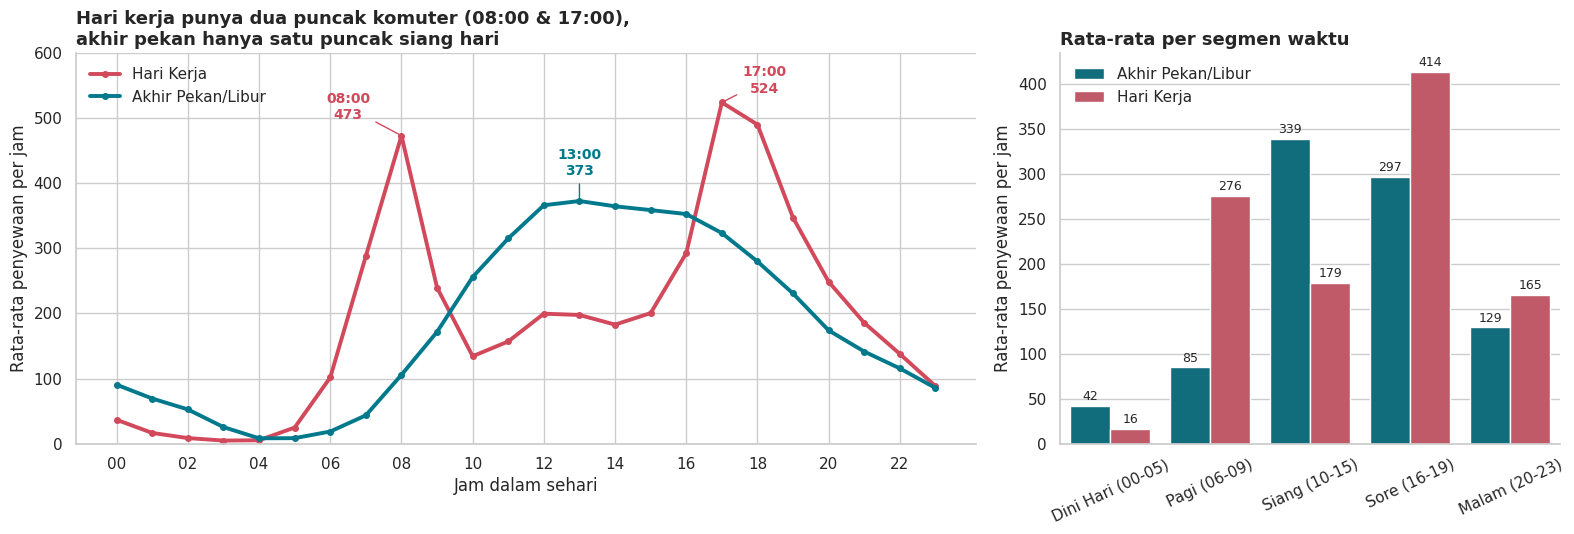

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.8, 1]})

# --- Panel kiri: pola per jam ---
ax = axes[0]
ax.plot(hourly_pattern.index, hourly_pattern["Hari Kerja"], color=C_ACCENT, lw=2.8, marker="o", ms=4, label="Hari Kerja")
ax.plot(hourly_pattern.index, hourly_pattern["Akhir Pekan/Libur"], color=C_BLUE, lw=2.8, marker="o", ms=4, label="Akhir Pekan/Libur")

peaks = [("Hari Kerja", 8, C_ACCENT, (-1.5, 25)), ("Hari Kerja", 17, C_ACCENT, (1.2, 15)),
         ("Akhir Pekan/Libur", 13, C_BLUE, (0, 40))]
for tipe, jam, warna, (dx, dy) in peaks:
    val = hourly_pattern.loc[jam, tipe]
    ax.annotate(f"{jam:02d}:00\n{val:,.0f}", xy=(jam, val), xytext=(jam + dx, val + dy),
                ha="center", fontsize=10, color=warna, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=warna, lw=1))

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 2)])
ax.set_xlabel("Jam dalam sehari")
ax.set_ylabel("Rata-rata penyewaan per jam")
ax.set_title("Hari kerja punya dua puncak komuter (08:00 & 17:00),\nakhir pekan hanya satu puncak siang hari", loc="left", fontsize=13, fontweight="bold")
ax.set_ylim(0, 600)
ax.legend(frameon=False, loc="upper left")
sns.despine(ax=ax)

# --- Panel kanan: segmen waktu (manual grouping) ---
ax = axes[1]
seg = segment_pattern.reset_index().melt(id_vars="time_segment", var_name="day_type", value_name="cnt")
sns.barplot(data=seg, x="time_segment", y="cnt", hue="day_type", palette={"Hari Kerja": C_ACCENT, "Akhir Pekan/Libur": C_BLUE}, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=9, padding=2)
ax.set_xlabel("")
ax.set_ylabel("Rata-rata penyewaan per jam")
ax.set_title("Rata-rata per segmen waktu", loc="left", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False, title="")
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Penjelasan:** Grafik kiri memperlihatkan bentuk permintaan yang berbeda. Hari kerja didorong oleh komuter (dua puncak tajam pagi dan sore), akhir pekan didorong oleh aktivitas rekreasi (satu puncak landai siang hari). Grafik kanan merangkum pola ini dalam 5 segmen waktu hasil manual grouping, sehingga lebih mudah dipakai untuk perencanaan operasional.

### Pertanyaan 2: Seberapa besar cuaca, musim, dan suhu memengaruhi penyewaan?

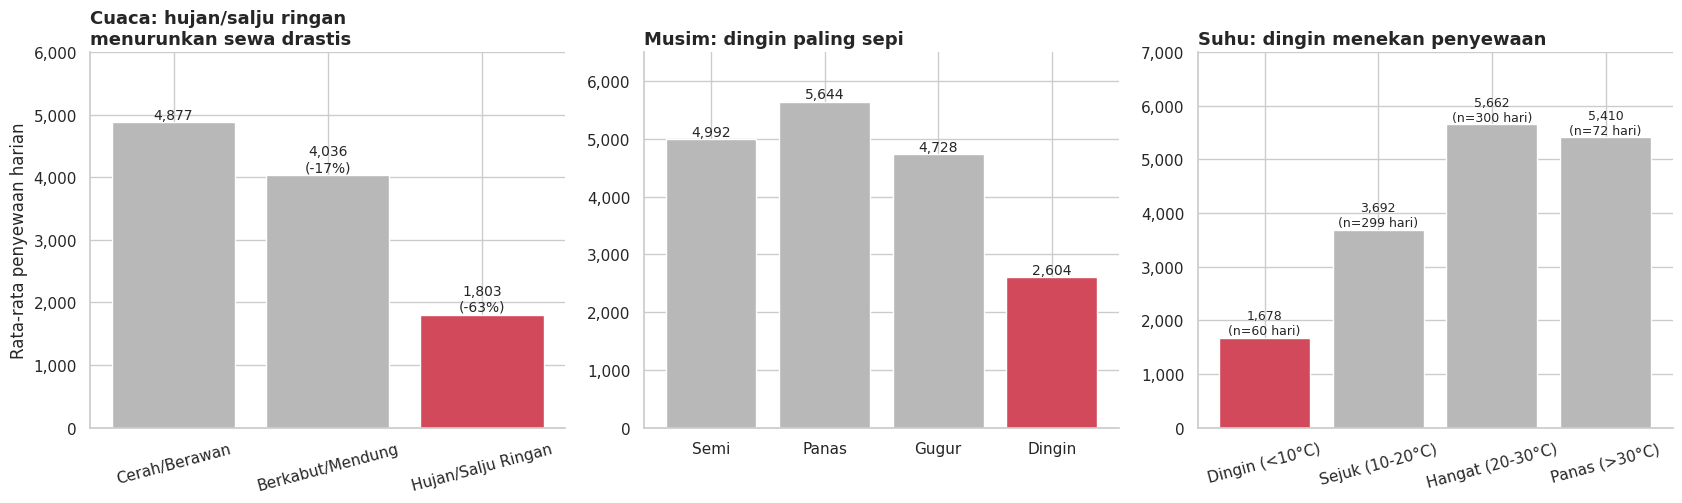

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# --- Cuaca ---
ax = axes[0]
colors = [C_GREY, C_GREY, C_ACCENT]
bars = ax.bar(weather_avg.index, weather_avg["rata2_sewa_harian"], color=colors)
for bar, pct in zip(bars, weather_avg["selisih_vs_cerah_%"]):
    label = f"{bar.get_height():,.0f}" + ("" if pct == 0 else f"\n({pct:+.0f}%)")
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, label, ha="center", fontsize=10)
ax.set_title("Cuaca: hujan/salju ringan\nmenurunkan sewa drastis", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Rata-rata penyewaan harian")
ax.set_ylim(0, 6000)
ax.tick_params(axis="x", rotation=15)

# --- Musim ---
ax = axes[1]
colors = [C_ACCENT if s == season_avg.idxmin() else C_GREY for s in season_avg.index]
bars = ax.bar(season_avg.index, season_avg.values, color=colors)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{bar.get_height():,.0f}", ha="center", fontsize=10)
ax.set_title("Musim: dingin paling sepi", loc="left", fontsize=13, fontweight="bold")
ax.set_ylim(0, 6500)

# --- Suhu (binning) ---
ax = axes[2]
colors = [C_ACCENT if v == temp_avg["rata2_sewa_harian"].min() else C_GREY for v in temp_avg["rata2_sewa_harian"]]
bars = ax.bar(temp_avg.index.astype(str), temp_avg["rata2_sewa_harian"], color=colors)
for bar, n in zip(bars, temp_avg["jumlah_hari"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{bar.get_height():,.0f}\n(n={n} hari)", ha="center", fontsize=9)
ax.set_title("Suhu: dingin menekan penyewaan", loc="left", fontsize=13, fontweight="bold")
ax.set_ylim(0, 7000)
ax.tick_params(axis="x", rotation=15)

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Penjelasan:** Ketiga faktor menunjukkan arah yang sama. Penyewaan turun saat cuaca memburuk, saat musim dingin, dan saat suhu rendah. Hujan/salju ringan dan suhu di bawah 10°C adalah dua kondisi dengan penurunan paling tajam (63% dan 70%). Sebaliknya, kondisi hangat 20-30°C adalah kondisi permintaan tertinggi.

### Pertanyaan 3: Kapan pengguna casual paling aktif?

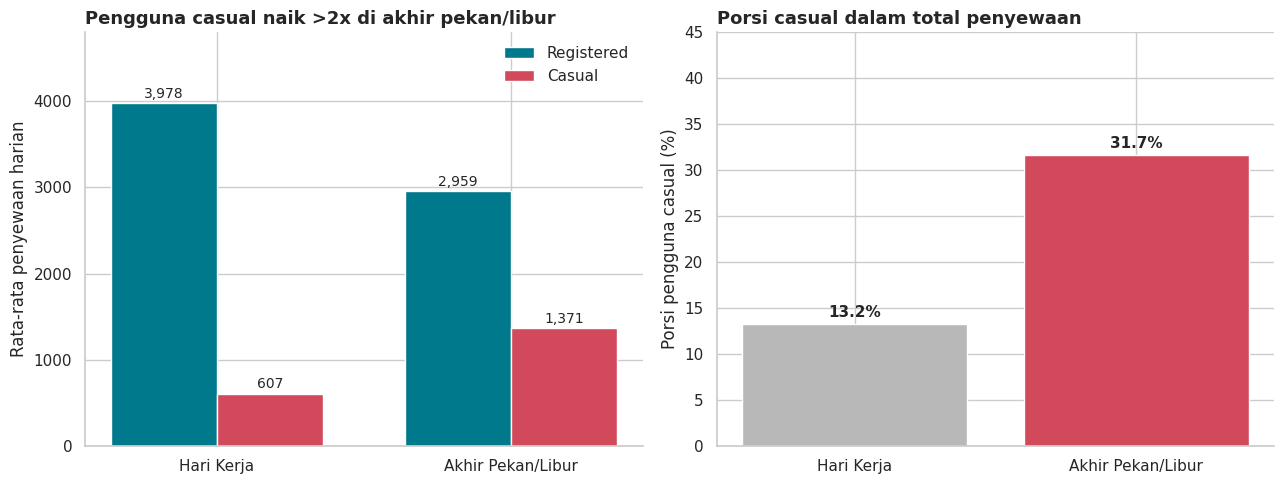

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ["Hari Kerja", "Akhir Pekan/Libur"]
data = user_avg.loc[order]

# --- Rata-rata per tipe pengguna ---
ax = axes[0]
x = np.arange(len(order)); w = 0.36
b1 = ax.bar(x - w / 2, data["registered"], w, color=C_BLUE, label="Registered")
b2 = ax.bar(x + w / 2, data["casual"], w, color=C_ACCENT, label="Casual")
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 60, f"{b.get_height():,.0f}", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("Rata-rata penyewaan harian")
ax.set_ylim(0, 4800)
ax.set_title("Pengguna casual naik >2x di akhir pekan/libur", loc="left", fontsize=13, fontweight="bold")
ax.legend(frameon=False)

# --- Porsi casual ---
ax = axes[1]
bars = ax.bar(order, data["casual_share_%"], color=[C_GREY, C_ACCENT])
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f"{b.get_height():.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Porsi pengguna casual (%)")
ax.set_ylim(0, 45)
ax.set_title("Porsi casual dalam total penyewaan", loc="left", fontsize=13, fontweight="bold")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Penjelasan:** Akhir pekan/libur adalah momentum utama pengguna casual. Mereka lebih dari dua kali lipat hari kerja, dan menyumbang hampir sepertiga penyewaan. Ini adalah segmen yang paling potensial untuk dikonversi menjadi pelanggan berlangganan.

## Analisis Lanjutan (Tanpa Machine Learning)
Teknik yang diterapkan dan tujuannya:
- **Manual Grouping** (`time_segment`): mengelompokkan 24 jam menjadi 5 segmen waktu berdasarkan pemahaman domain (jam komuter, siang, malam). Tujuannya agar operator dapat merencanakan distribusi sepeda per periode, bukan per jam.
- **Binning** (`temp_bin`): mengelompokkan suhu kontinu menjadi 4 kategori dengan `pd.cut`. Tujuannya agar pengaruh suhu mudah dikomunikasikan dan dipakai sebagai ambang keputusan.
- RFM dan geospatial analysis tidak diterapkan karena dataset tidak memiliki ID pelanggan maupun koordinat lokasi.

## Conclusion

### Kesimpulan

**Pertanyaan 1 (pola jam sibuk).** Permintaan hari kerja memuncak pada **08:00 (473 sewa/jam)** dan **17:00 (524 sewa/jam)**, sedangkan akhir pekan/libur memuncak pada **13:00 (373 sewa/jam)**. Pada jam 17:00, hari kerja 62% lebih tinggi daripada akhir pekan/libur. Pola ini menunjukkan sepeda di hari kerja dipakai untuk komuter, di akhir pekan untuk rekreasi.

**Pertanyaan 2 (pengaruh cuaca).** Hujan/salju ringan menurunkan penyewaan harian sebesar **63%** dibanding cuaca cerah, dan musim dingin **54% lebih rendah** daripada musim panas. Suhu di bawah 10°C adalah kategori terendah (**70% di bawah** kategori hangat 20-30°C). Suhu berkorelasi positif kuat dengan penyewaan (0,63). Catatan: ada tren pertumbuhan 2012 terhadap 2011 yang ikut memengaruhi perbandingan antar-musim, dan sampel hari hujan/salju ringan hanya 21 hari.

**Pertanyaan 3 (perilaku pengguna).** Pengguna casual naik **126%** pada akhir pekan/libur dan porsinya naik dari **13,2% menjadi 31,7%** dari total penyewaan, sementara pengguna registered turun 26%.

### Rekomendasi (Action Items)
1. **Redistribusi sepeda mengikuti pola jam.** Hari kerja: isi stok di area perkantoran dan stasiun transit sebelum 07:00 dan 16:00. Akhir pekan/libur: pindahkan stok ke area rekreasi dan wisata sekitar 10:00-15:00. Jadwalkan perawatan armada pada jam sepi 02:00-05:00 hari kerja.
2. **Strategi cuaca dan musim.** Siapkan promo atau insentif untuk hari hujan ringan dan suhu di bawah 10°C, serta jadwalkan servis besar armada pada musim dingin saat permintaan terendah. Pastikan armada maksimal tersedia pada kondisi hangat (20-30°C).
3. **Konversi pengguna casual.** Tawarkan promo membership (misalnya potongan biaya bulanan atau uji coba gratis) pada akhir pekan/libur, ketika pengguna casual paling aktif dan mudah dijangkau.

## Simpan Data untuk Dashboard

In [31]:
# Simpan data bersih untuk dashboard
import os
os.makedirs("dashboard", exist_ok=True)
hour_df.to_csv("dashboard/main_data.csv", index=False)   # level jam
day_df.to_csv("dashboard/day_data.csv", index=False)     # level hari
print("Data dashboard tersimpan.")

Data dashboard tersimpan.
